In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.instance().ast_node_interactivity = "all"
from sklearn.dummy import DummyClassifier

c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_validation.csv")

In [4]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def extract_features(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    analysis = ProteinAnalysis(sequence.replace("-", ""))
    features = counts.copy()
    features["Hydrophobicity"] = analysis.gravy()
    features["Isoelectric point"] = analysis.isoelectric_point()
    features["Aromaticity"] = analysis.aromaticity()
    features["Instability index"] = analysis.instability_index()
    features["Molecular weight"] = analysis.molecular_weight()
    features["Charge"] = analysis.charge_at_pH(7.0)
    
    return features

In [5]:
train_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR1 aligned']])
train_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR2 aligned']])
train_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR3 aligned']])


In [6]:
train_cdr1.columns = [f"CDR1_{aa}" for aa in train_cdr1.columns]
train_cdr2.columns = [f"CDR2_{aa}" for aa in train_cdr2.columns]
train_cdr3.columns = [f"CDR3_{aa}" for aa in train_cdr3.columns]

In [7]:
val_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR1 aligned']])
val_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR2 aligned']])
val_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR3 aligned']])


In [8]:
val_cdr1.columns = [f"CDR1_{aa}" for aa in val_cdr1.columns]
val_cdr2.columns = [f"CDR2_{aa}" for aa in val_cdr2.columns]
val_cdr3.columns = [f"CDR3_{aa}" for aa in val_cdr3.columns]


In [9]:
x_train = pd.concat([train_cdr1, train_cdr2, train_cdr3], axis=1)
y_train = train_df['Label'].values
x_val = pd.concat([val_cdr1, val_cdr2, val_cdr3], axis=1)
y_val = val_df['Label'].values


In [10]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,              
    min_samples_leaf=3,       
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
clf.fit(x_train, y_train)
print("Number of features:", clf.n_features_in_)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

Number of features: 81


In [11]:
print(type(clf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [12]:
print("Train columns:", x_train.columns[:5])
print("Val columns:", x_val.columns[:5])

Train columns: Index(['CDR1_A', 'CDR1_C', 'CDR1_D', 'CDR1_E', 'CDR1_F'], dtype='object')
Val columns: Index(['CDR1_A', 'CDR1_C', 'CDR1_D', 'CDR1_E', 'CDR1_F'], dtype='object')


In [13]:
x_val = x_val[x_train.columns]

In [14]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.58125
Precision: 0.533384497313891
Recall: 0.566884176182708
F1 Score: 0.549624357453539

Confusion Matrix:
 [[886 608]
 [531 695]]

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.59      0.61      1494
           1       0.53      0.57      0.55      1226

    accuracy                           0.58      2720
   macro avg       0.58      0.58      0.58      2720
weighted avg       0.58      0.58      0.58      2720


ROC AUC Score: 0.6186371369108844


In [ ]:
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.6007678327104903
Validation Accuracy: 0.58125


In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


Baseline accuracy: 0.549264705882353


In [17]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)

Average precision: 0.5636735147189793
PR AUC (AUC over PR curve): 0.5632531041447392


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall curve (AP = 0.564)')

(0.0, 1.05)

(0.0, 1.0)

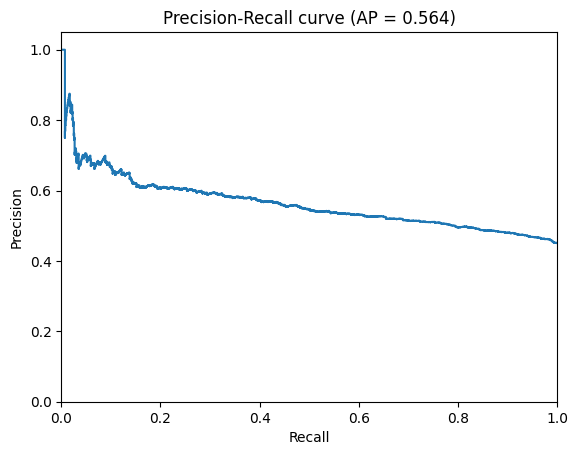

In [ ]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

<Figure size 1000x600 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_16124\3492647688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')


<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Top 20 Feature Importances (Amino Acids in CDRs)')

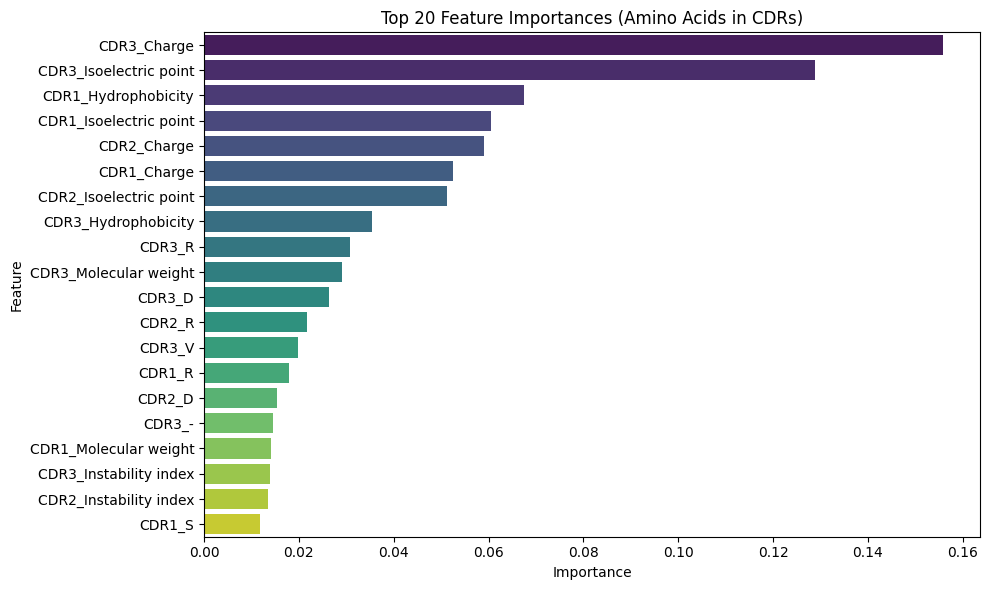

In [ ]:
feat_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (Amino Acids in CDRs)')
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_16124\3959690622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')


<Axes: xlabel='Importance', ylabel='Group'>

Text(0.5, 1.0, 'Grouped Feature Importance by CDR Region')

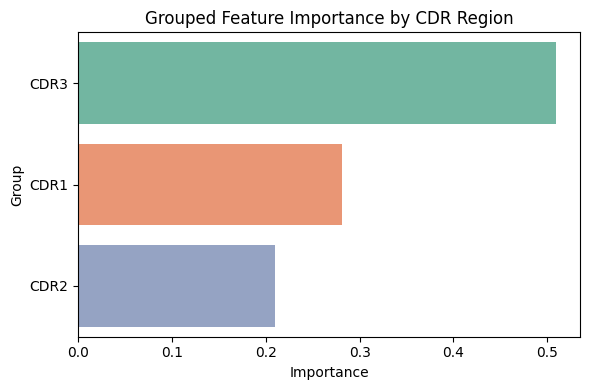

In [ ]:
feat_df['Group'] = feat_df['Feature'].astype(str).str.extract(r'^(CDR\d+)_')
group_importance = feat_df.groupby('Group')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')
plt.title('Grouped Feature Importance by CDR Region')
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_16124\2369169635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')


<Axes: xlabel='Importance', ylabel='AA'>

Text(0.5, 1.0, 'Amino Acid Importance (All CDRs)')

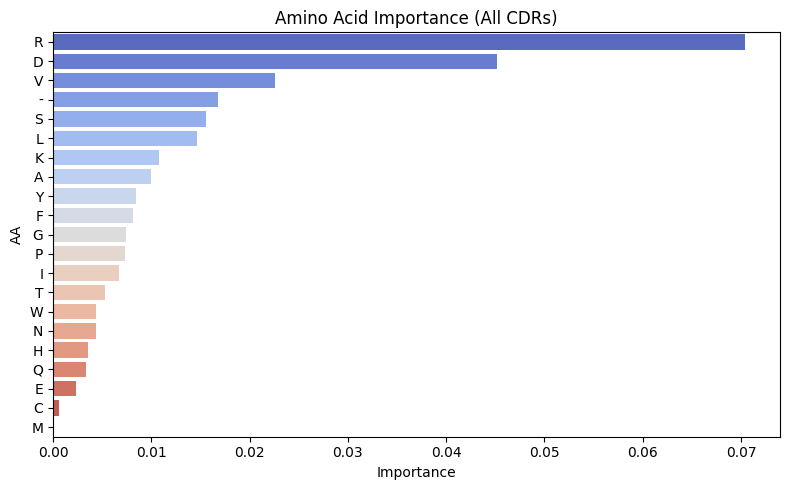

In [ ]:
feat_df['AA'] = feat_df['Feature'].str.extract(r'_([A-Z\-])$')  
aa_importance = feat_df.groupby('AA')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')
plt.title('Amino Acid Importance (All CDRs)')
plt.tight_layout()
plt.show()


Test set evaluation

In [22]:
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")

In [23]:
test_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR1 aligned']])
test_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR2 aligned']])
test_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR3 aligned']])


In [24]:
test_cdr1.columns = [f"CDR1_{aa}" for aa in test_cdr1.columns]
test_cdr2.columns = [f"CDR2_{aa}" for aa in test_cdr2.columns]
test_cdr3.columns = [f"CDR3_{aa}" for aa in test_cdr3.columns]

In [25]:
x_test = pd.concat([test_cdr1, test_cdr2, test_cdr3], axis=1)
y_test = test_df['Label'].values
clusters_test = test_df["Cluster_number"].values

In [26]:
x_test = x_test[x_train.columns]

In [30]:
val_test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_test.csv")
val_test_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR1 aligned']])
val_test_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR2 aligned']])
val_test_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_test_df['CDR3 aligned']])
val_test_cdr1.columns = [f"CDR1_{aa}" for aa in val_test_cdr1.columns]
val_test_cdr2.columns = [f"CDR2_{aa}" for aa in val_test_cdr2.columns]
val_test_cdr3.columns = [f"CDR3_{aa}" for aa in val_test_cdr3.columns]
x_test_val = pd.concat([val_test_cdr1, val_test_cdr2, val_test_cdr3], axis=1)
y_test_val = val_test_df['Label'].values
clusters_test_val = val_test_df["Cluster_number"].values

In [31]:
def evaluate_split(clf, x, y, split_name="Test"):
    y_scores = clf.predict_proba(x)[:, 1]
    y_pred = (y_scores >= 0.5).astype(int)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    cm = confusion_matrix(y, y_pred)

    roc_auc = roc_auc_score(y, y_scores)
    p, r, _ = precision_recall_curve(y, y_scores)
    pr_auc = auc(r, p)

    print(f"\n================ FULL {split_name.upper()} SET ================\n")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print("\nConfusion matrix:")
    print(cm)
    print(f"\nROC-AUC:   {roc_auc:.3f}")
    print(f"PR-AUC:    {pr_auc:.3f}")

    return {
        "y_scores": y_scores,
        "y_pred": y_pred,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "cm": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }


In [32]:

def evaluate_at_k(y_true, y_scores, clusters, k=100, split_name="Test"):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)
    clusters = np.asarray(clusters)

    assert len(y_true) == len(y_scores), "y_true and y_scores must have same length"
    assert len(y_true) == len(clusters), "y_true and clusters must have same length"

    k = min(k, len(y_true))
    top_idx = np.argsort(y_scores)[::-1][:k]
    y_topk = y_true[top_idx]

    # precision@k
    precision_k = y_topk.sum() / k
    total_positives = y_true.sum()

    # precision@1000
    k_1000 = min(1000, len(y_true))
    top_idx_1000 = np.argsort(y_scores)[::-1][:k_1000]
    precision_1000 = y_true[top_idx_1000].sum() / k_1000

    # ef@k
    positive_rate = total_positives / len(y_true)
    ef_k = (precision_k / positive_rate) if positive_rate > 0 else np.nan

    # diversity@k
    diversity_k = len(np.unique(clusters[top_idx]))

    # normalized diversity@k
    total_unique_clusters = len(np.unique(clusters))
    normalized_diversity_k = (
        diversity_k / total_unique_clusters if total_unique_clusters > 0 else np.nan
    )
    
    print(f"\n================ {split_name.upper()} @ {k} ================\n")

    print(f"Precision@{k}:            {precision_k:.3f}")
    print(f"Precision@1000:           {precision_1000:.3f}")
    print(f"EF@{k}:                   {ef_k:.3f}" if not np.isnan(ef_k) else f"EF@{k}:NaN")

    print(f"Diversity@{k}:            {diversity_k}")
    print(f"Normalized Diversity@{k}: {normalized_diversity_k:.3f}" 
      if not np.isnan(normalized_diversity_k) 
      else f"Normalized Diversity@{k}: NaN")

    return {
        "top_idx": top_idx,
        f"precision@{k}": precision_k,
        f"precision@1000": precision_1000,
        f"ef@{k}": ef_k,
        f"diversity@{k}": diversity_k,
        f"normalized_diversity@{k}": normalized_diversity_k
    }


In [33]:
test_results = evaluate_split(clf, x_test, y_test, split_name="Test")
test_at_100 = evaluate_at_k(y_test, test_results["y_scores"], clusters_test, k=100, split_name="Test")

val_test_results = evaluate_split(clf, x_test_val, y_test_val, split_name="Validation")
val_test_at_100 = evaluate_at_k(y_test_val, val_test_results["y_scores"], clusters_test_val, k=100, split_name="Validation")


================ FULL TEST SET ================

Accuracy:  0.575
Precision: 0.561
Recall:    0.572
F1:        0.566

Confusion matrix:
[[10881  7950]
 [ 7609 10149]]

ROC-AUC:   0.609
PR-AUC:    0.592

================ TEST @ 100 ================

Precision@100:            0.850
Precision@1000:           0.739
EF@100:                   1.751
Diversity@100:            94
Normalized Diversity@100: 0.005

================ FULL VALIDATION SET ================

Accuracy:  0.578
Precision: 0.530
Recall:    0.562
F1:        0.546

Confusion matrix:
[[884 611]
 [536 689]]

ROC-AUC:   0.614
PR-AUC:    0.561

================ VALIDATION @ 100 ================

Precision@100:            0.710
Precision@1000:           0.557
EF@100:                   1.576
Diversity@100:            88
Normalized Diversity@100: 0.039


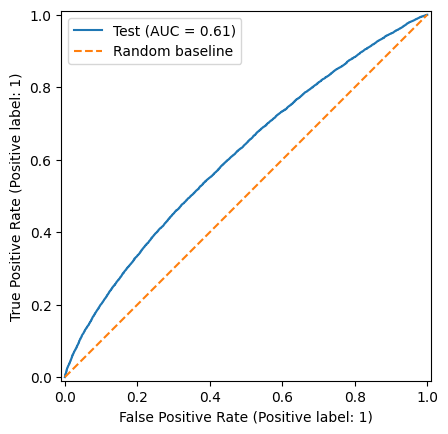

In [34]:
RocCurveDisplay.from_predictions(y_test, test_results["y_scores"], name="Test")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.legend()
plt.show()

In [ ]:
model_name = "RF_CDRs_Physicochemical_Properties"
seq_sim = 70

metrics_row = pd.DataFrame({
    "Model": [model_name],
    "Sequence_Similarity": [seq_sim],
    "Accuracy_test": [test_results["acc"]],
    "Precision_test": [test_results["prec"]],
    "Recall_test": [test_results["rec"]],
    "F1_test": [test_results["f1"]],
    "ROC_AUC_test": [test_results["roc_auc"]],
    "PR_AUC_test": [test_results["pr_auc"]],

    "Precision@100_test": [test_at_100["precision@100"]],
    "Precision@1000_test": [test_at_100["precision@1000"]],
    "EF@100_test": [test_at_100["ef@100"]],
    "Diversity@100_test": [test_at_100["diversity@100"]],
    "Normalized_Diversity@100_test": [test_at_100["normalized_diversity@100"]],

    "Precision@100_val": [val_test_at_100["precision@100"]],
    "Precision@1000_val": [val_test_at_100["precision@1000"]],
    "EF@100_val": [val_test_at_100["ef@100"]],
    "Diversity@100_val": [val_test_at_100["diversity@100"]],
    "Normalized_Diversity@100_val": [val_test_at_100["normalized_diversity@100"]],

    "N_test": [len(y_test)],
    "N_val": [len(y_test_val)]
})

metrics_file = r"D:\Thesis EGFR Round 3\Baseline Models\Results\metrics_all_models_70.csv"

metrics_row.to_csv(
    metrics_file,
    mode='a',
    header=not os.path.exists(metrics_file),
    index=False
)

print("Metrics saved.")

Metrics saved.


In [ ]:
def get_topk_df(df, y_true, y_scores, y_pred, top_idx):
    topk_df = df.iloc[top_idx].copy().assign(
        y_true=y_true[top_idx],
        pred_score=y_scores[top_idx],
        pred_label=y_pred[top_idx]
    )
    tp_topk_df = topk_df[
        (topk_df["y_true"] == 1) & (topk_df["pred_label"] == 1)
    ].copy()
    return tp_topk_df

In [ ]:
tp_top100_df = get_topk_df(test_df, y_test, test_results["y_scores"], test_results["y_pred"], test_at_100["top_idx"])
export_df = tp_top100_df[[
    "Cluster_number",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence",
    "CDR_sequence"
]]

In [39]:
export_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\Predictions\regularized_count_cdrs_chemical.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))

Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 85


SHAP values

In [40]:
x_top = x_test.iloc[test_at_100["top_idx"]]

shap_inter: (100, 81, 81, 2) X: (100, 81)


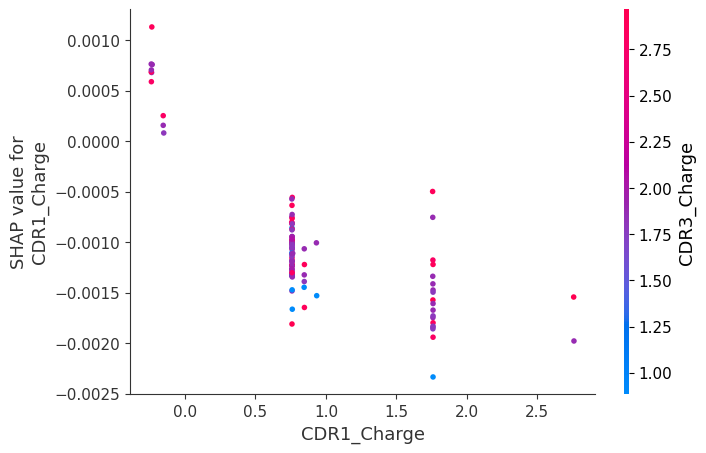

In [ ]:
target_class = 1
explainer_interaction = shap.TreeExplainer(clf)

shap_inter = explainer_interaction.shap_interaction_values(x_top)
if isinstance(shap_inter, list):
    shap_inter = shap_inter[target_class]

print("shap_inter:", shap_inter.shape, "X:", x_top.shape) 

feature_names = list(x_top.columns)
i = feature_names.index("CDR1_Charge")
j = feature_names.index("CDR3_Charge")

target_class = 1  
ij = shap_inter[:, i, j, target_class]
sv_ij = np.zeros((x_top.shape[0], x_top.shape[1]))
sv_ij[:, i] = ij

shap.dependence_plot(i, sv_ij, x_top, interaction_index=j, feature_names=feature_names)

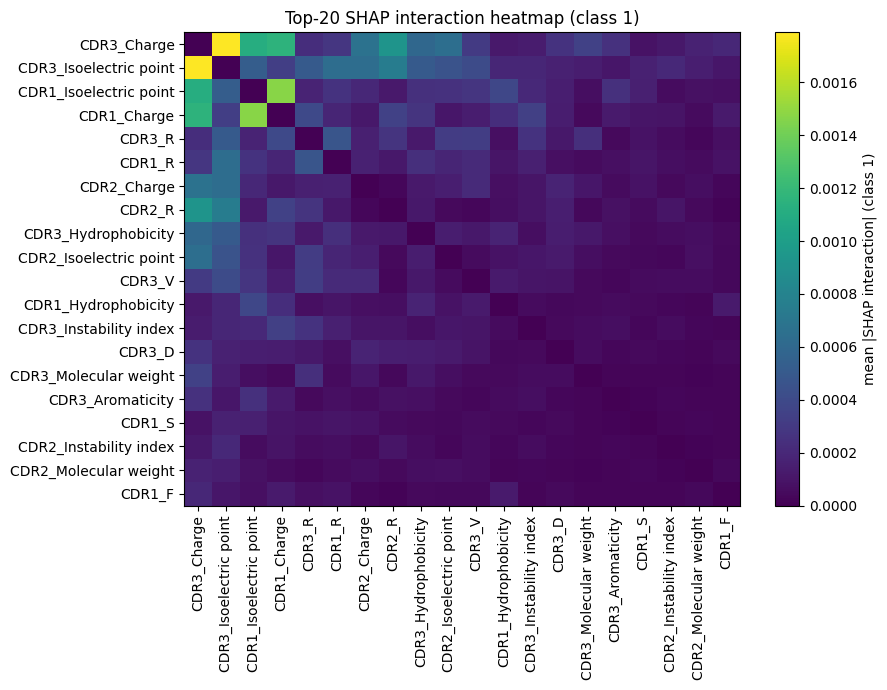

Top interaction features: ['CDR3_Charge', 'CDR3_Isoelectric point', 'CDR1_Isoelectric point', 'CDR1_Charge', 'CDR3_R', 'CDR1_R', 'CDR2_Charge', 'CDR2_R', 'CDR3_Hydrophobicity', 'CDR2_Isoelectric point', 'CDR3_V', 'CDR1_Hydrophobicity', 'CDR3_Instability index', 'CDR3_D', 'CDR3_Molecular weight', 'CDR3_Aromaticity', 'CDR1_S', 'CDR2_Instability index', 'CDR2_Molecular weight', 'CDR1_F']


In [ ]:

def plot_topk_interaction_heatmap(shap_inter, X, target_class=1, k=20, zero_diag=True):
    feature_names = list(X.columns)
    SI = shap_inter[:, :, :, target_class]              
    M = np.abs(SI).mean(axis=0)                        

    if zero_diag:
        np.fill_diagonal(M, 0.0)

    scores = M.sum(axis=0) + M.sum(axis=1)
    top_idx = np.argsort(-scores)[:k]

    M_top = M[np.ix_(top_idx, top_idx)]
    names_top = [feature_names[i] for i in top_idx]

    plt.figure(figsize=(9, 7))
    im = plt.imshow(M_top, aspect="auto")
    plt.colorbar(im, label="mean |SHAP interaction| (class 1)")
    plt.xticks(range(k), names_top, rotation=90)
    plt.yticks(range(k), names_top)
    plt.title(f"Top-{k} SHAP interaction heatmap (class 1)")
    plt.tight_layout()
    plt.show()

    return names_top, M_top

top_features, M_top = plot_topk_interaction_heatmap(shap_inter, x_top, target_class=1, k=20)
print("Top interaction features:", top_features)

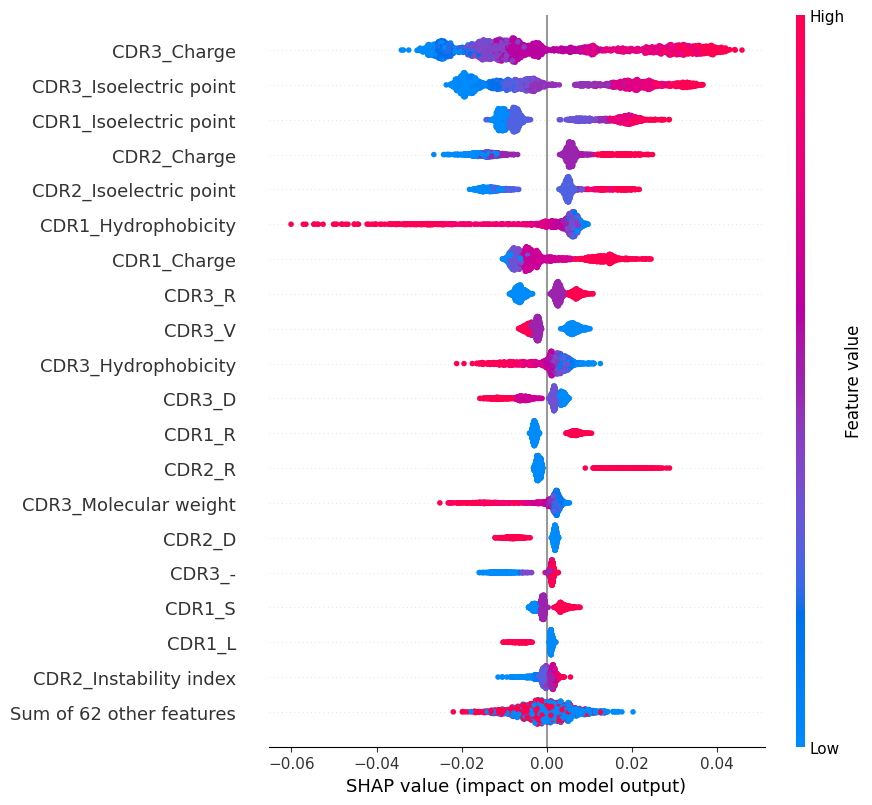

In [ ]:
subset = x_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(clf)
sv = explainer(subset)

if sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )

shap.plots.beeswarm(sv, max_display=20)

Number of label 1 sequences in top-100: 85


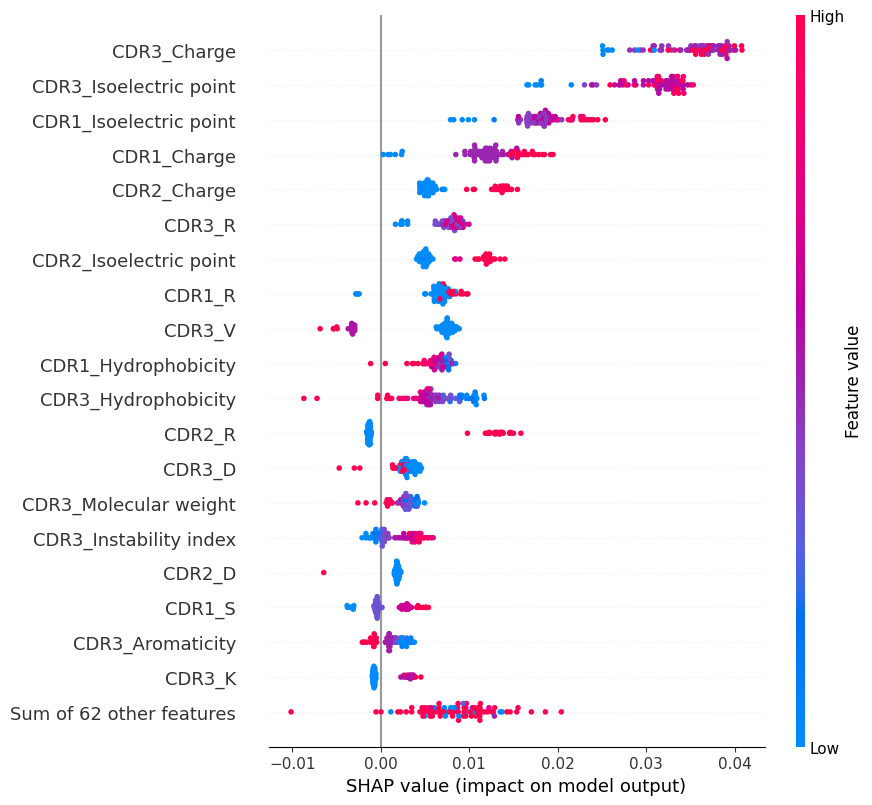

In [44]:
k =100
top_idx_shap = np.argsort(-test_results["y_scores"])[:k]
top100_label1_idx = top_idx_shap[y_test[top_idx_shap] == 1]
print("Number of label 1 sequences in top-100:", len(top100_label1_idx))
subset_top100_pos = x_test.iloc[top100_label1_idx]
explainer_100 = shap.TreeExplainer(clf)
sv_100 = explainer_100(subset_top100_pos)

if sv_100.values.ndim == 3:
    class_idx = 1
    sv_100 = shap.Explanation(
        values=sv_100.values[:, :, class_idx],
        base_values=sv_100.base_values[:, class_idx],
        data=sv_100.data,
        feature_names=sv_100.feature_names
    )

shap.plots.beeswarm(sv_100, max_display=20)


Top-5 indices: [29433 29953 19051 34400 26856]
Top-5 scores : [0.68653939 0.68652028 0.68260534 0.68072626 0.67836236]
Top-5 labels : [1 1 1 1 1]

=== Rank 1 | x_test idx=29433 | score=0.6865 | y=1 ===


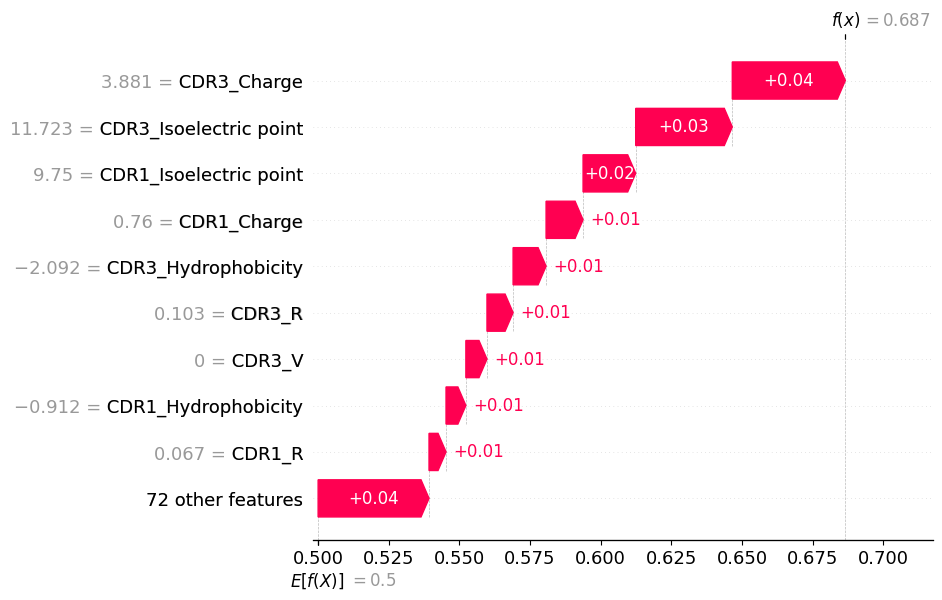


=== Rank 2 | x_test idx=29953 | score=0.6865 | y=1 ===


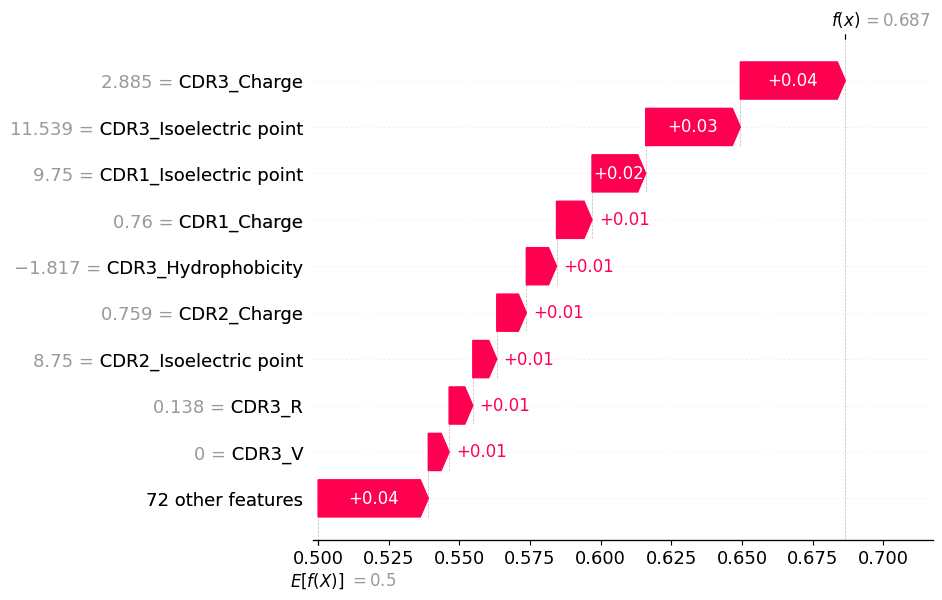


=== Rank 3 | x_test idx=19051 | score=0.6826 | y=1 ===


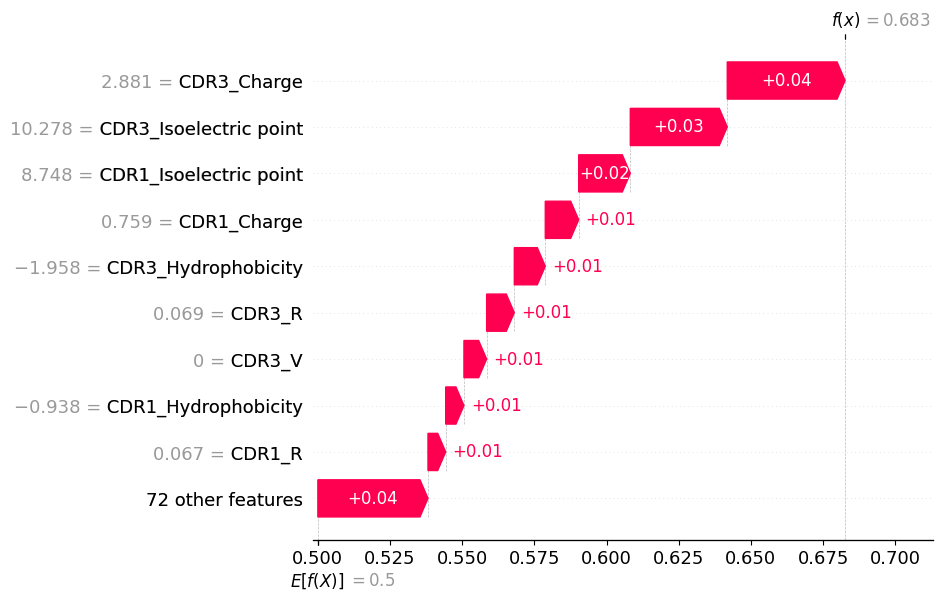


=== Rank 4 | x_test idx=34400 | score=0.6807 | y=1 ===


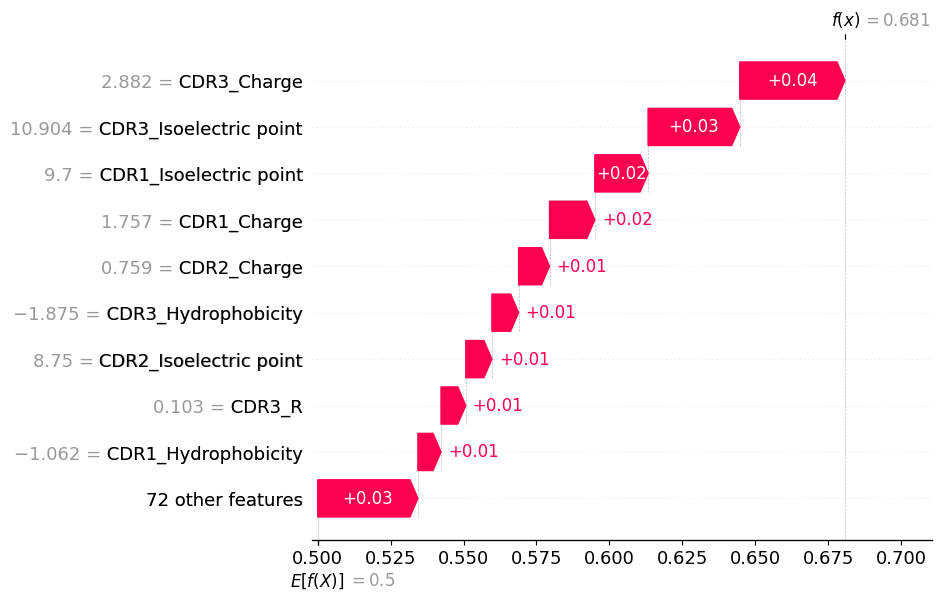


=== Rank 5 | x_test idx=26856 | score=0.6784 | y=1 ===


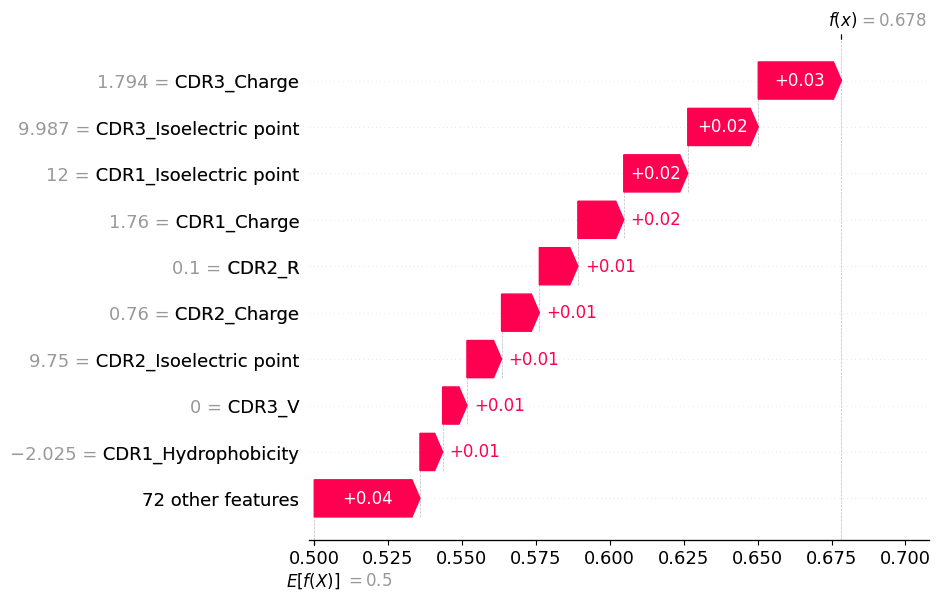

In [ ]:

label1_idx = np.where(y_test == 1)[0]
label1_scores = test_results["y_scores"][label1_idx]

k_top = 5
top5_label1_local = np.argsort(-label1_scores)[:k_top]
top5_idx = label1_idx[top5_label1_local]

top5_X = x_test.iloc[top5_idx]

print("Top-5 indices:", top5_idx)
print("Top-5 scores :", test_results["y_scores"][top5_idx])
print("Top-5 labels :", y_test[top5_idx])   

explainer_5 = shap.TreeExplainer(clf)
sv_5 = explainer_5(top5_X)

if sv_5.values.ndim == 3:
    class_idx = 1
    sv_5 = shap.Explanation(
        values=sv_5.values[:, :, class_idx],
        base_values=sv_5.base_values[:, class_idx],
        data=sv_5.data,
        feature_names=sv_5.feature_names
    )

for i in range(k_top):
    print(f"\n=== Rank {i+1} | x_test idx={top5_idx[i]} | score={test_results["y_scores"][top5_idx[i]]:.4f} | y={y_test[top5_idx[i]]} ===")
    shap.plots.waterfall(sv_5[i], max_display=10)
